## ¿Qué departamentos concentran la mayor carga de divorcios y cómo ha evolucionado esto en el tiempo? 

    Los divorcios no se distribuyen uniformemente; se asume que existe una concentración de tipo Pareto donde pocos departamentos acumulan la mayoría de los casos, y que esta tendencia es estructural (constante en el tiempo). 

Cargando datos desde data_pipeline...

--- Análisis de Concentración (Pareto) ---
                  Total  Pct_Acumulado
departamento                          
Guatemala       24378.0      36.703353
Quetzaltenango   5115.0      44.404463
Escuintla        3305.0      49.380448
San Marcos       2915.0      53.769253
Jutiapa          2795.0      57.977386
Suchitepéquez    2377.0      61.556181
Huehuetenango    2321.0      65.050663
Izabal           2094.0      68.203376
Santa Rosa       1953.0      71.143799
Retalhuleu       1920.0      74.034538


C:\Users\richi\AppData\Local\Temp\ipykernel_17280\1875069240.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pareto_df.index, rotation=45, ha='right', fontsize=9)


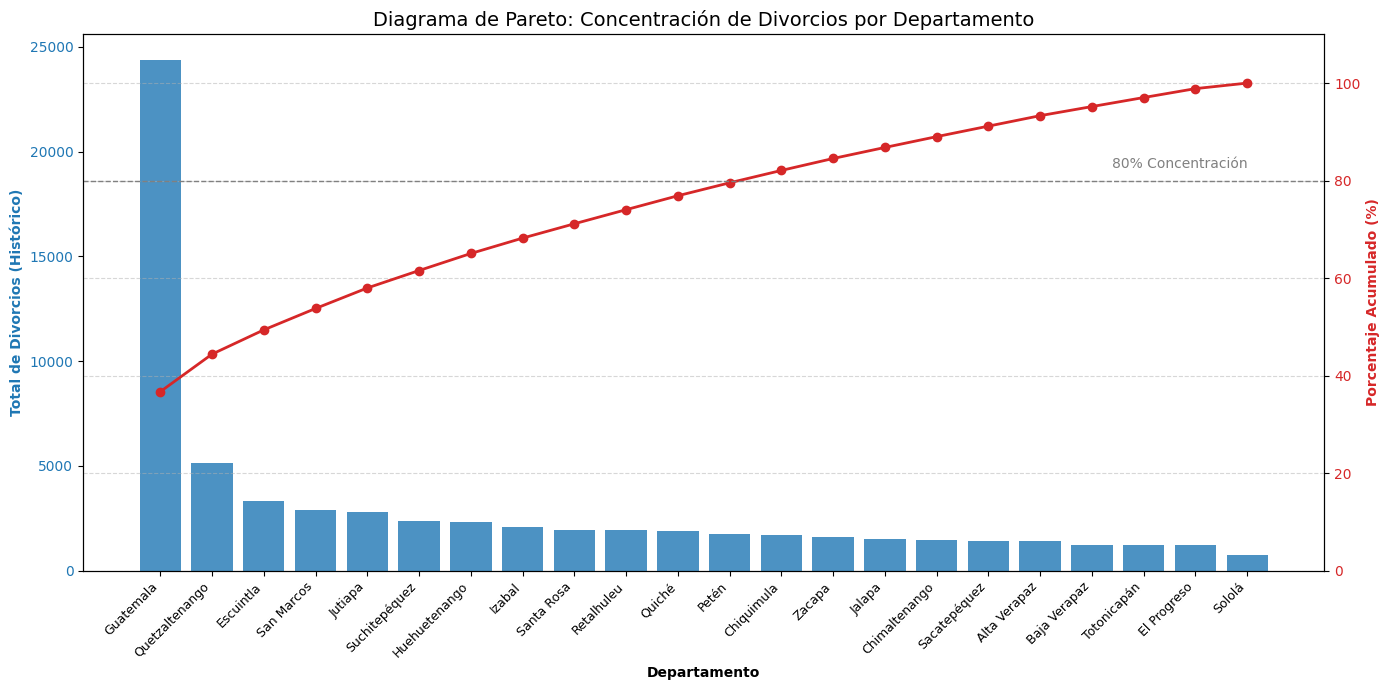


--- Análisis de Evolución Temporal ---


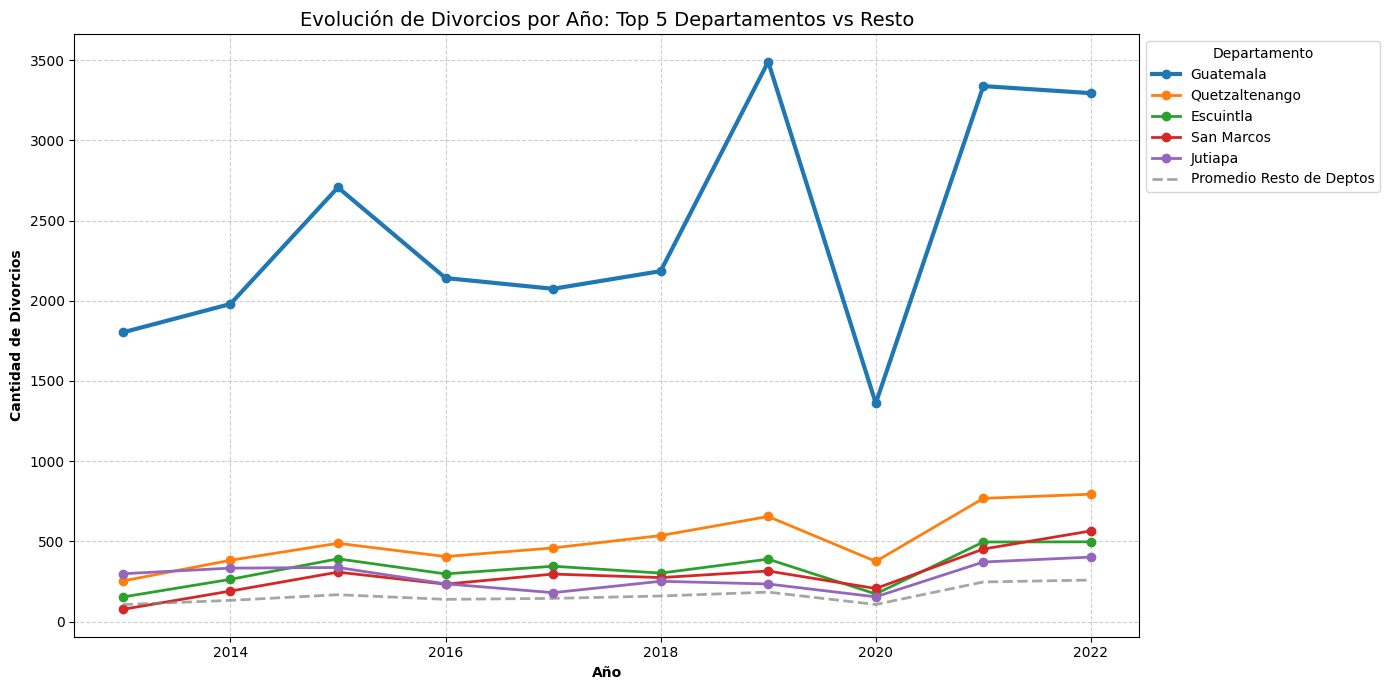

In [2]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# ---------------------------------------------------------
# CONFIGURACIÓN DEL ENTORNO
# ---------------------------------------------------------
# Aseguramos que Python pueda encontrar 'data_pipeline.py'
# Si estás ejecutando esto desde 'Analisis_Exploratorio_EDA', el pipeline está un nivel arriba.
project_root = Path.cwd() 
if project_root.name in ['Analisis_Exploratorio_EDA', 'Preguntas_De_Investgacion']:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    
import data_pipeline as dp
# ---------------------------------------------------------
# 1. CARGA Y PREPARACIÓN DE DATOS
# ---------------------------------------------------------
print("Cargando datos desde data_pipeline...")
try:
    # only_common_years=False para ver todo el historial de divorcios disponible
    df = dp.build_panel(force_rebuild=False, only_common_years=False)
except Exception as e:
    print(f"Error cargando los datos: {e}")
    raise
# Filtramos registros válidos para el análisis de divorcios
df_div = df.dropna(subset=['divorcios_total', 'departamento']).copy()
# ---------------------------------------------------------
# 2. CONCENTRACIÓN DE DIVORCIOS (Análisis de Pareto)
# ---------------------------------------------------------
print("\n--- Análisis de Concentración (Pareto) ---")
# Agrupar por departamento y sumar histórico
pareto_data = df_div.groupby('departamento')['divorcios_total'].sum().sort_values(ascending=False)
total_divorcios = pareto_data.sum()
# Calcular métricas acumuladas
pareto_df = pd.DataFrame({
    'Total': pareto_data,
    'Porcentaje': (pareto_data / total_divorcios) * 100,
    'Acumulado': pareto_data.cumsum(),
    'Pct_Acumulado': (pareto_data.cumsum() / total_divorcios) * 100
})
print(pareto_df.head(10)[['Total', 'Pct_Acumulado']])
# --- GRÁFICO 1: PARETO ---
fig, ax1 = plt.subplots(figsize=(14, 7))
# Barras: Total Divorcios
ax1.bar(pareto_df.index, pareto_df['Total'], color='#1f77b4', label='Total Divorcios', alpha=0.8)
ax1.set_xlabel('Departamento', fontweight='bold')
ax1.set_ylabel('Total de Divorcios (Histórico)', color='#1f77b4', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticklabels(pareto_df.index, rotation=45, ha='right', fontsize=9)
# Línea: Porcentaje Acumulado (Eje secundario)
ax2 = ax1.twinx()
ax2.plot(pareto_df.index, pareto_df['Pct_Acumulado'], color='#d62728', marker='o', linewidth=2, label='% Acumulado')
ax2.set_ylabel('Porcentaje Acumulado (%)', color='#d62728', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.set_ylim(0, 110)
# Línea de referencia del 80% (Ley de Pareto)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.text(len(pareto_df)-1, 82, '80% Concentración', color='gray', ha='right', va='bottom')
plt.title('Diagrama de Pareto: Concentración de Divorcios por Departamento', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
# ---------------------------------------------------------
# 3. EVOLUCIÓN TEMPORAL (Series de Tiempo)
# ---------------------------------------------------------
print("\n--- Análisis de Evolución Temporal ---")
# Seleccionamos los departamentos del Top 5 según el Pareto anterior
top_5_deptos = pareto_df.head(5).index.tolist()
# Pivoteamos tabla: Años vs Departamentos
pivot_df = df_div.pivot_table(index='anio', columns='departamento', values='divorcios_total', aggfunc='sum').fillna(0)
# Datos para graficar: Top 5 y Promedio del Resto
plot_df = pivot_df[top_5_deptos].copy()
plot_df['Resto (Promedio)'] = pivot_df.drop(columns=top_5_deptos).mean(axis=1)
# --- GRÁFICO 2: SERIES DE TIEMPO ---
plt.figure(figsize=(14, 7))
# Graficamos cada columna del top 5
for col in top_5_deptos:
    # Resaltamos al líder (probablemente Guatemala) con una línea más gruesa
    linewidth = 3 if col == top_5_deptos[0] else 2
    plt.plot(plot_df.index, plot_df[col], marker='o', linewidth=linewidth, label=col)
# Graficamos el promedio del resto como referencia
plt.plot(plot_df.index, plot_df['Resto (Promedio)'], 
         color='gray', linestyle='--', linewidth=2, label='Promedio Resto de Deptos', alpha=0.7)
plt.title('Evolución de Divorcios por Año: Top 5 Departamentos vs Resto', fontsize=14)
plt.xlabel('Año', fontweight='bold')
plt.ylabel('Cantidad de Divorcios', fontweight='bold')
plt.legend(title='Departamento', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()